In [15]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [17]:
from google.colab import files

uploaded = files.upload()

Saving Country-data.csv to Country-data (1).csv


In [18]:
df = pd.read_csv("Country-data.csv")   # Use the exact file name you uploaded

print(df.columns)

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


In [19]:
df.columns = df.columns.str.strip()

df = df.drop_duplicates()

for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.fillna(df.median(numeric_only=True), inplace=True)
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [21]:
X = df.drop("country", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 1.29153238 -1.13827979  0.27908825 -0.08245496 -0.8082454   0.15733622
  -1.61909203  1.90288227 -0.67917961]
 [-0.5389489  -0.47965843 -0.09701618  0.07083669 -0.3753689  -0.31234747
   0.64786643 -0.85997281 -0.48562324]
 [-0.27283273 -0.09912164 -0.96607302 -0.64176233 -0.22084447  0.78927429
   0.67042323 -0.0384044  -0.46537561]
 [ 2.00780766  0.77538117 -1.44807093 -0.16531531 -0.58504345  1.38705353
  -1.17923442  2.12815103 -0.51626829]
 [-0.69563412  0.1606679  -0.28689415  0.4975675   0.10173177 -0.60174853
   0.70425843 -0.54194633 -0.04181713]]


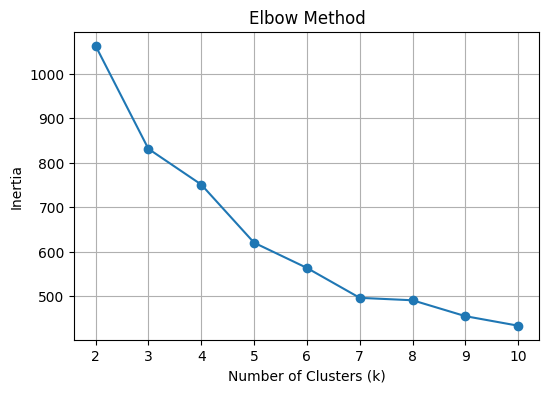

In [22]:
inertia = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [23]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans.fit(X_scaled)

clusters = kmeans.labels_
print(clusters[:10])

[2 0 0 2 0 0 0 1 1 0]


In [24]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.285600988953231


In [25]:
dbscan = DBSCAN(eps=1.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)
print(dbscan_labels[:10])

[ 0  0  0 -1  0  0  0  0  0  0]


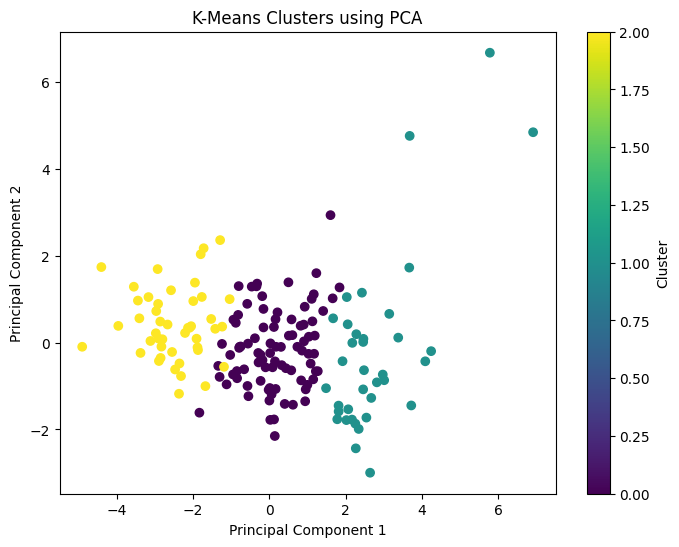

In [26]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')

plt.title("K-Means Clusters using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()

In [27]:
df["Cluster"] = clusters

df.groupby("Cluster").mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


## Section 14: Observations

1. The cluster with the highest child mortality and the lowest life expectancy represents low-development countries.

2. The cluster with the highest income and GDP per capita represents economically developed countries.

3. The remaining cluster represents developing countries with moderate income and development levels.

4. The PCA scatter plot shows that countries are grouped into three distinct clusters based on their socio-economic characteristics.

5. The Silhouette Score indicates that the K-Means model forms reasonably good clusters.